# SETTING UP MODEL

## define and imports

In [37]:
import os
import time
import random
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm

import matplotlib.pyplot as plt

In [38]:
DEVICE = (
    "mps" if torch.backends.mps.is_available()
    else ("cuda" if torch.cuda.is_available() else "cpu")
)
print("Device:", DEVICE)

# -----------------------------
# Data config
# -----------------------------
DATA_ROOT = "data/imagenette2-160"
BATCH_SIZE = 64
NUM_WORKERS = 2
IMG_SIZE = 224

# -----------------------------
# BO config (head-only)
# -----------------------------
SEED = 42
EPOCHS_PER_TRIAL = 1

N_INIT = 8
N_TRIALS = 30
NUM_RESTARTS = 10
RAW_SAMPLES = 256


Device: mps


### Seed and dataloader

In [39]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def make_dataloaders(batch_size: int):
    train_tfms = transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ])
    val_tfms = transforms.Compose([
        transforms.Resize(int(IMG_SIZE * 1.14)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ])

    train_ds = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), transform=train_tfms)
    val_ds = datasets.ImageFolder(os.path.join(DATA_ROOT, "val"), transform=val_tfms)

    pin = (DEVICE == "cuda")
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)

    return train_ds, val_ds, train_dl, val_dl

## Model


In [40]:
def build_model(num_classes: int):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def freeze_backbone_forever(model: nn.Module):
    for name, p in model.named_parameters():
        if name.startswith("fc."):
            p.requires_grad = True
        else:
            p.requires_grad = False

def make_optimizer_head_only(model: nn.Module, lr_head: float, weight_decay: float):
    return torch.optim.AdamW(model.fc.parameters(), lr=lr_head, weight_decay=weight_decay)

## Training and evaluation

In [41]:
@torch.no_grad()
def evaluate(model, val_dl, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0

    for x, y in val_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        n += x.size(0)

    return total_loss / n, correct / n

def train_one_epoch(model, train_dl, optimizer, criterion):
    model.train()
    total_loss, n = 0.0, 0

    for x, y in tqdm(train_dl, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        n += x.size(0)

    return total_loss / n

# BAYESIAN OPTIMIZATION

In [42]:
from skopt import gp_minimize
from skopt.space import Real
from skopt.space import Categorical
from skopt.space import Integer
from skopt import dummy_minimize

space = [
    Real(1e-6, 1e-2, prior="log-uniform", name="weight_decay"),
    # Real(1e-4, 3e-2, prior="log-uniform", name="lr_head"),
    Real(0.0, 0.5, name="dropout"),
    Categorical(["adam", "sgd"], name="optimizer"),
    Integer(64, 512, name="hidden_dim")
]

In [43]:
counter = 0  
current_history = None


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

train_ds, val_ds, train_dl, val_dl = make_dataloaders(BATCH_SIZE)


def objective(params):
    global counter
    counter += 1
    print(f"Trial number {counter}")
    print("Params:", params)
    weight_decay, dropout, optimizer_name,hidden_dim = params
    set_all_seeds(SEED + counter)

    model = build_model(num_classes=10).to(DEVICE)
    freeze_backbone_forever(model)

    criterion = nn.CrossEntropyLoss()
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, hidden_dim),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_dim, 10)
    )
    model = model.to(DEVICE)

    head_params = model.fc.parameters()
    
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(
            head_params,
            lr=0.0001,
            weight_decay=weight_decay
        )
    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(
            head_params,
            lr=0.0001,
            weight_decay=weight_decay,
            momentum=0.9
        )
    
    model = model.to(DEVICE)   # ← ADD THIS

    for _ in range(EPOCHS_PER_TRIAL):
        train_one_epoch(model, train_dl, optimizer, criterion)
    
    val_loss, val_acc = evaluate(model, val_dl, criterion)
    if current_history is not None:
        current_history.append(val_acc)
    return val_loss  # minimize

### BAYESIAN OPTIMIZER

In [65]:
counter = 0
bo_val_acc_history = []
current_history = bo_val_acc_history
xi = 1
result_bo = gp_minimize(
    func=objective,
    dimensions=space,
    n_calls=20,          # must be > n_initial_points
    n_initial_points=5,  # first 5 are random
    acq_func="EI",
    xi=xi,             # optional, explicit
    random_state=SEED,
)

print("Best params:", result_bo.x)
print("Best val loss:", result_bo.fun)

Trial number 1
Params: [0.001535224694197351, 0.09171739493308191, 'sgd', 331]


Trial number 2
Params: [6.071989493441303e-05, 0.049987457909001456, 'adam', 214]


Trial number 3
Params: [3.727925903376984e-06, 0.3254442364744265, 'adam', 387]


Trial number 4
Params: [0.005678201970293135, 0.0003893829205071643, 'sgd', 341]


Trial number 5
Params: [0.0002796485951606247, 0.003533152609858704, 'adam', 299]


...

Trial number 17
Params: [0.002940341312608711, 0.48460928196347924, 'sgd', 262]


Trial number 18
Params: [0.009458597658772843, 0.49445758967934467, 'adam', 242]


Trial number 19
Params: [0.00018252660509833016, 0.0028365835364606022, 'adam', 70]


Trial number 20
Params: [0.001271600679790079, 0.0035342906259117632, 'sgd', 506]


Best params: [1.1543948819064977e-06, 0.022205600730810574, 'adam', 505]
Best val loss: 0.29871089842668763


### DUMMY OPTIMIZER

In [70]:
counter = 0
random_val_acc_history = []
current_history = random_val_acc_history

result_random = dummy_minimize(
    func=objective,
    dimensions=space,
    n_calls=20,          # same budget as BO
    random_state=SEED,
)

Trial number 1
Params: [0.001535224694197351, 0.09171739493308191, 'sgd', 331]


Trial number 2
Params: [6.071989493441303e-05, 0.049987457909001456, 'adam', 214]


Trial number 3
Params: [3.727925903376984e-06, 0.3254442364744265, 'adam', 387]


Trial number 4
Params: [0.005678201970293135, 0.0003893829205071643, 'sgd', 341]


Trial number 5
Params: [0.0002796485951606247, 0.003533152609858704, 'adam', 299]


...

Trial number 16
Params: [0.0009756194291174571, 0.26984606619453994, 'sgd', 496]


Trial number 17
Params: [0.0002680013555822699, 0.1379995910112717, 'adam', 138]


Trial number 18
Params: [1.1549033124221253e-06, 0.21170074035318487, 'adam', 195]


Trial number 19
Params: [1.1384639705304639e-06, 0.0994212020444026, 'sgd', 418]


Trial number 20
Params: [0.0002653627132902634, 0.4631504392566746, 'sgd', 474]


### PLOTTING

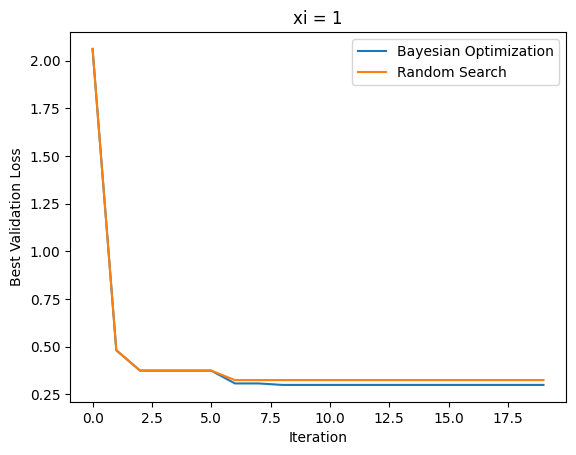

In [71]:
bo_losses = result_bo.func_vals


bo_best = np.minimum.accumulate(bo_losses)
rand_best = np.minimum.accumulate(result_random.func_vals)



plt.plot(bo_best, label="Bayesian Optimization")
plt.plot(rand_best, label="Random Search")
plt.xlabel("Iteration")
plt.ylabel("Best Validation Loss")
plt.legend()
plt.title(f"xi = {xi}")
plt.show()

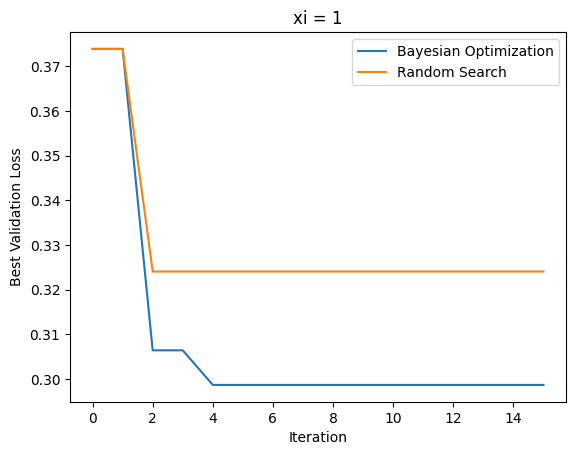

In [72]:
plt.plot(bo_best[4:], label="Bayesian Optimization")
plt.plot(rand_best[4:], label="Random Search")
plt.xlabel("Iteration")
plt.ylabel("Best Validation Loss")
plt.title(f"xi = {xi}")
plt.legend()
plt.show()

In [ ]:
rann

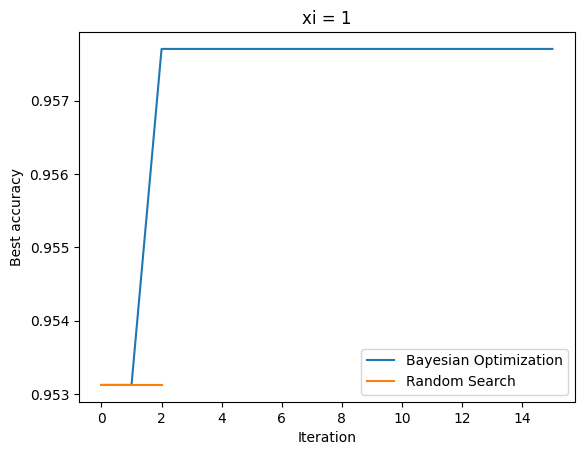

In [69]:
plt.plot(np.maximum.accumulate(bo_val_acc_history[4:]), label="Bayesian Optimization")
plt.plot(np.maximum.accumulate(random_val_acc_history[4:]), label="Random Search")
plt.xlabel("Iteration")
plt.ylabel("Best accuracy")
plt.title(f"xi = {xi}")
plt.legend()
plt.show()

In [63]:
res = result_bo  # dit resultat-objekt
X = res.x_iters      # liste af param-lister (én per iteration)
y = res.func_vals    # objective value per iteration

print("Best x:", res.x)
print("Best y:", res.fun)

# første 10 forslag
for i, (x, yi) in enumerate(zip(X, y)):
    print(i, x, yi)

Best x: [2.3700678069768233e-06, 0.0023724013054189923, 'adam', 512]
Best y: 0.2767135150645189
0 [0.001535224694197351, 0.09171739493308191, 'sgd', 331] 2.0614263837656397
1 [6.071989493441303e-05, 0.049987457909001456, 'adam', 214] 0.4806289764118802
2 [3.727925903376984e-06, 0.3254442364744265, 'adam', 387] 0.3738319455134641
3 [0.005678201970293135, 0.0003893829205071643, 'sgd', 341] 2.079713694882241
4 [0.0002796485951606247, 0.003533152609858704, 'adam', 299] 0.3769924649007761
5 [0.01, 2.7450270670715607e-18, 'adam', 512] 0.2836075806314019
6 [2.0720517351277864e-05, 0.49926983312090695, 'adam', 512] 0.33875215606324993
7 [0.009436405203346793, 0.489990309154218, 'adam', 430] 0.42009842755688226
8 [1e-06, 2.083429457192897e-20, 'adam', 512] 0.2848120960308488
9 [2.3700678069768233e-06, 0.0023724013054189923, 'adam', 512] 0.2767135150645189
10 [2.325825249273285e-06, 0.46145198919123137, 'adam', 67] 1.072023046912661
11 [0.0004224005399746125, 0.21487654142006324, 'adam', 512] 0.

In [73]:
import pandas as pd

# Kolonnenavne
cols = ["weight_decay", "dropout", "optimizer", "hidden layer dim"]

# Lav dataframe
df = pd.DataFrame(X, columns=cols)

# Rund lidt så det ser pænere ud
df["weight_decay"] = df["weight_decay"].map(lambda x: f"{x:.2e}")
df["dropout"] = df["dropout"].round(3)

df

,weight_decay,dropout,optimizer,hidden layer dim
0,1.54e-03,0.092,sgd,331
1,6.07e-05,0.050,adam,214
2,3.73e-06,0.325,adam,387
3,5.68e-03,0.000,sgd,341
4,2.80e-04,0.004,adam,299
5,1.00e-02,0.000,adam,512
6,2.07e-05,0.499,adam,512
7,9.44e-03,0.490,adam,430
8,1.00e-06,0.000,adam,512
9,2.37e-06,0.002,adam,512
